# <span style="color:black; font-weight:bold;">CosMx Human Lung Cancer Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 3.17.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 3.17.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Lung5_Rep1 data used in the tutorial are available at [Lung5_Rep1.h5ad](https://drive.google.com/file/d/1FH_jfPqtMygz_rKU6yZLRU9jXa6I4Kjw/edit). This data from [CosMx NSCLC FFPE Dataset](https://brukerspatialbiology.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/nsclc-ffpe-dataset/)

In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
import torch
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading CosMx Human Lung Cancer data</span>
The CosMx Mouse Brain data contains 100,292 cells and 960 genes.

In [4]:
adata=sc.read_h5ad('/home/dbj/SpaLP/Tutorialdata/Lung5_Rep1.h5ad')
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 100292 × 960
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI'
    obsm: 'spatial'

### <span style="color:black; font-weight:bold;">Preprocessing steps</span>

In [5]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.scale(adata)
adata.obsm['feat']=adata.X

### <span style="color:black; font-weight:bold;">Compute neighbor index matrix</span>
k: The number of k-nearest neighbors (Optional)

In [6]:
%%time
graph = prepare_inputs(adata,k=5, device=device)

CPU times: user 1.19 s, sys: 1.36 s, total: 2.56 s
Wall time: 1.18 s


### <span style="color:black; font-weight:bold;">Initialize the SpaLP model</span>

In [7]:
model = SpatialLocalPooling(in_channels=adata.obsm['feat'].shape[1], out_channels=64)

### <span style="color:black; font-weight:bold;">Model training (mode='single-slice')</span>
epochs:training epochs (Default:200)  
lr:Learning rate (Default:1e-3)     
device:Model training device    
seed:Random seed (Default:7)  
mode:single-slice/multi-slices

In [8]:
model.Train(graph=graph,epochs=200,lr=1e-3,device=device,seed=7,mode='single-slice')

Training(single-slices): 100%|█████████████████████████████████████████| 200/200 [00:07<00:00, 28.27it/s, Epoch=199, Loss=0.9472, PeakGPUmemory=2.73GB]


### <span style="color:black; font-weight:bold;">Output the reconstructed expression matrix and embedding (mode='single-slice')</span>

In [9]:
reconstructed, embedding = model.get_embedding(graph,mode='single-slice')

### <span style="color:black; font-weight:bold;">Save the reconstruction expression matrix and cell embedding</span>

In [10]:
adata.obsm['SpaLP']=embedding
adata.layers['rec']=reconstructed

### <span style="color:black; font-weight:bold;">Downstream analysis (leiden)</span>

In [11]:
%%time
sc.pp.neighbors(adata,use_rep='SpaLP')
sc.tl.leiden(adata, resolution=0.5,key_added='SpaLP')

CPU times: user 5min 39s, sys: 33.6 s, total: 6min 12s
Wall time: 3min 5s


### The spatial distribution of niche identification results

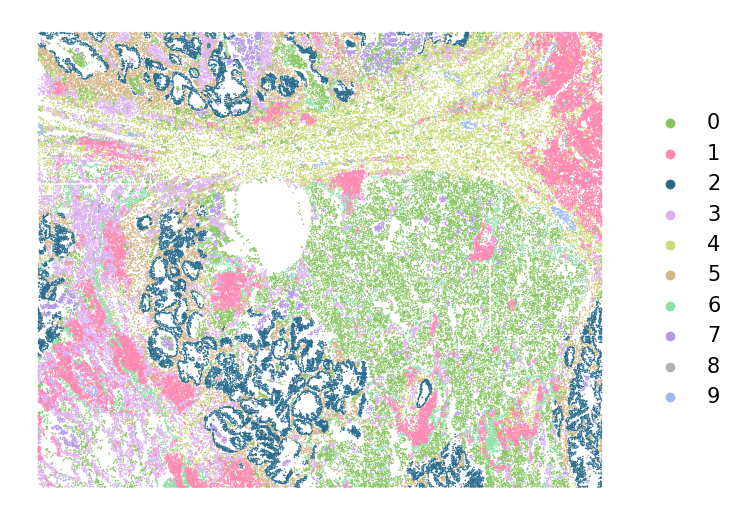

In [12]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,6.5)
plt.rcParams['font.size'] = 15
latent_cluster_colors = create_new_color_dict(adata=adata,cat_key='SpaLP',skip_default_colors=3)
sc.pl.embedding(adata=adata,color='SpaLP',title='',size=5,basis='spatial',colorbar_loc=None,frameon=False,palette=latent_cluster_colors)

<Axes: xlabel='spatial1', ylabel='spatial2'>

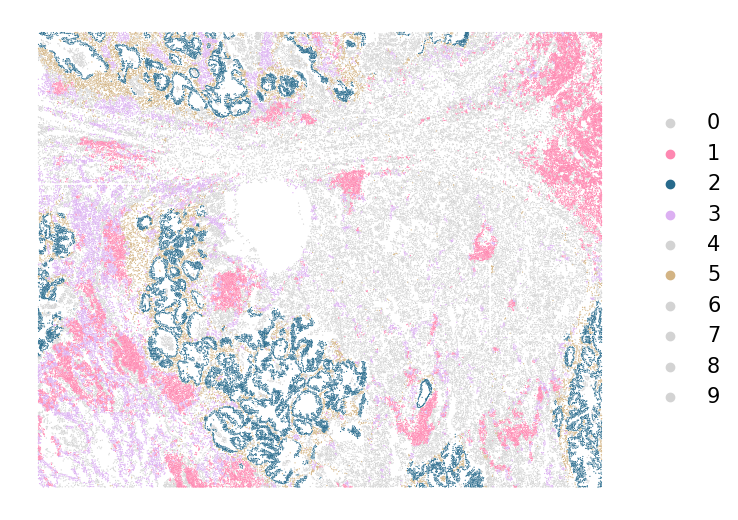

In [16]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,6.5)
plt.rcParams['font.size'] = 15

highlight_colors = copy.deepcopy(latent_cluster_colors)
targets = ['2', '5','3','1']
for k in highlight_colors.keys():
    if k not in targets:
        highlight_colors[k] = '#D3D3D3'
        
sc.pl.embedding(adata=adata,basis='spatial',color=['SpaLP'],frameon=False,title='',palette=highlight_colors,show=False,size=3)

### Spatial mapping of original and reconstructed gene expression

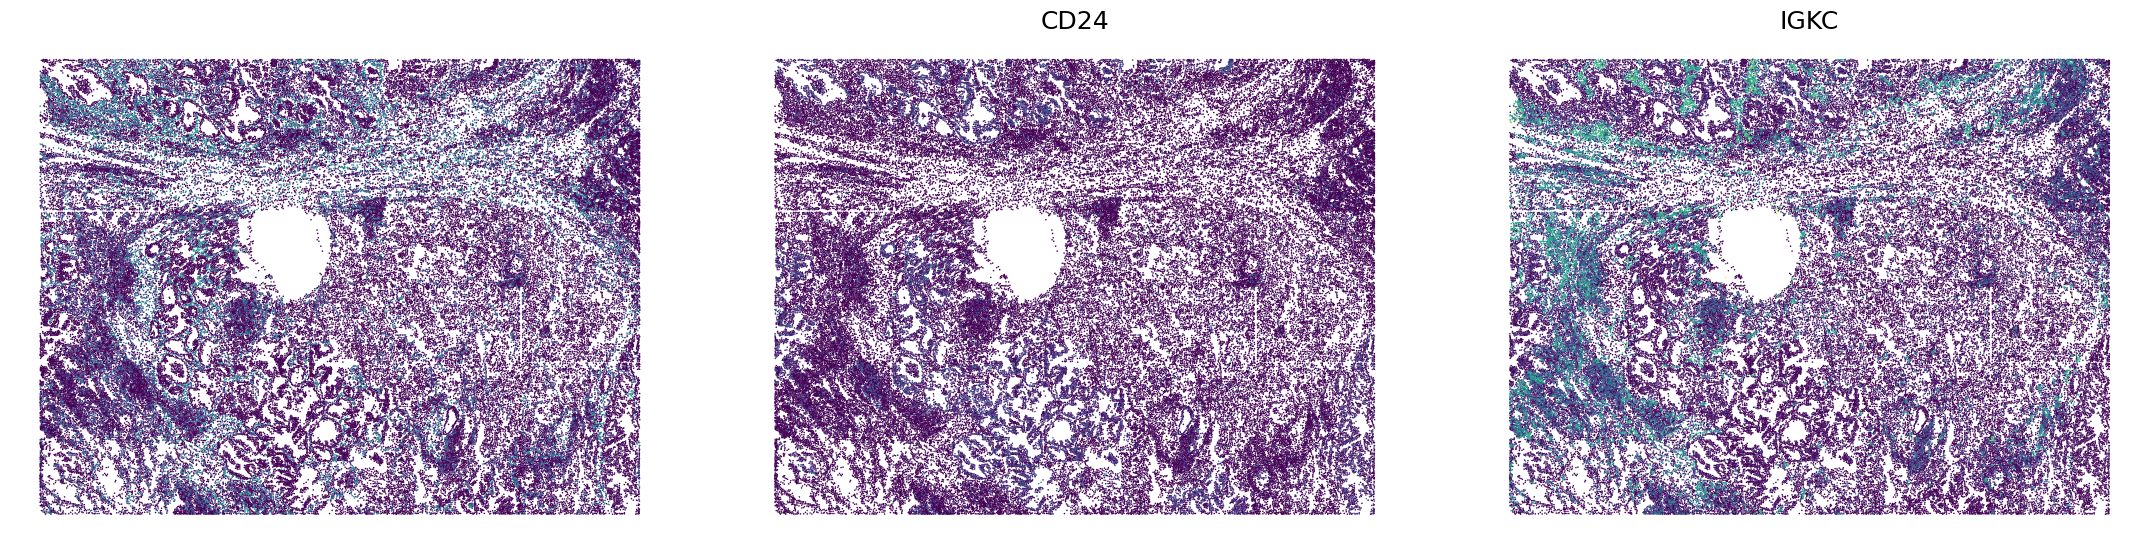

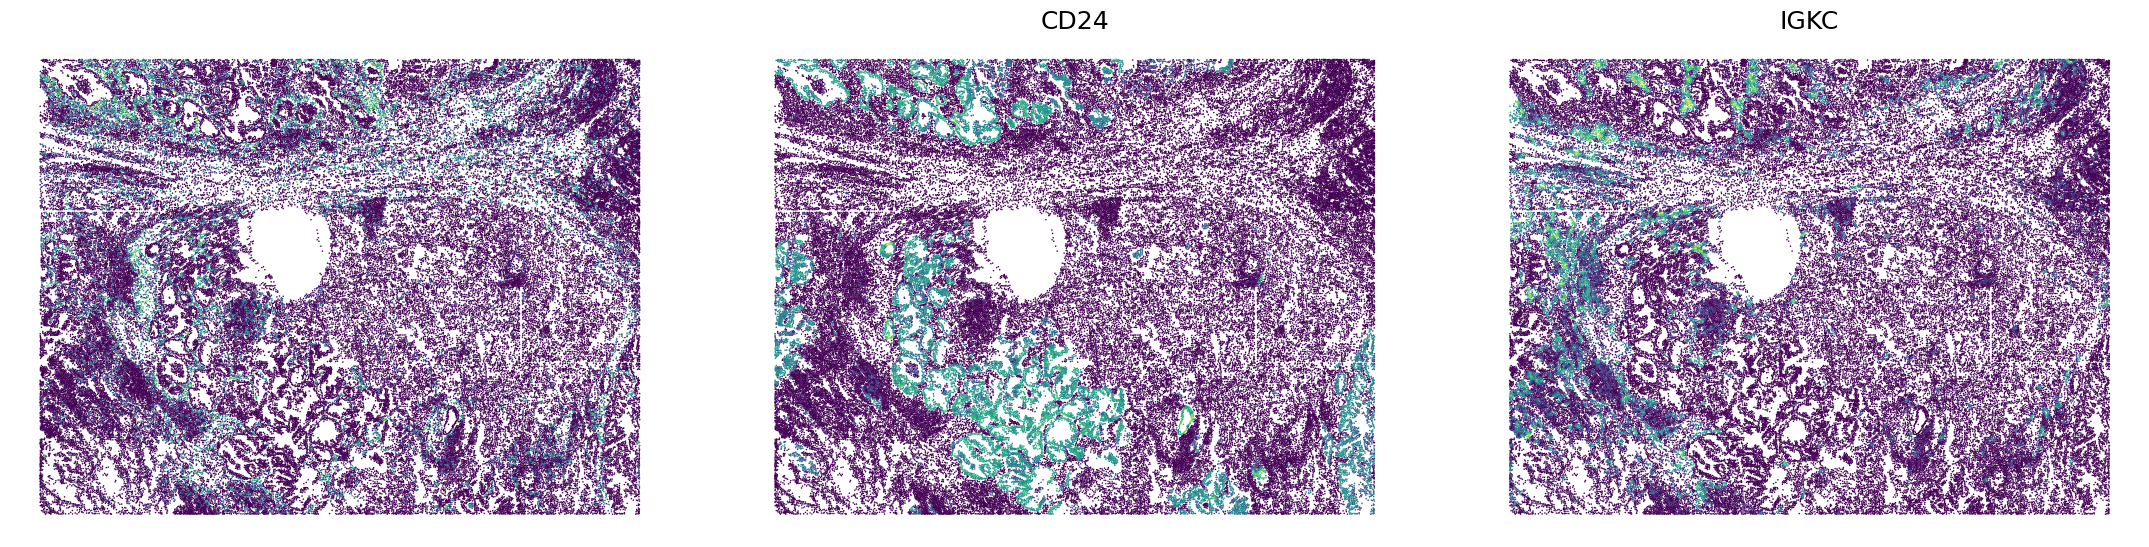

In [20]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (8,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata=adata,color=['FN1','CD24','IGKC'],title='',size=5,basis='spatial',colorbar_loc=None,frameon=False)
sc.pl.embedding(adata=adata,color=['FN1','CD24','IGKC'],title='',size=5,basis='spatial',colorbar_loc=None,frameon=False,layer='rec')

### gene co-localization

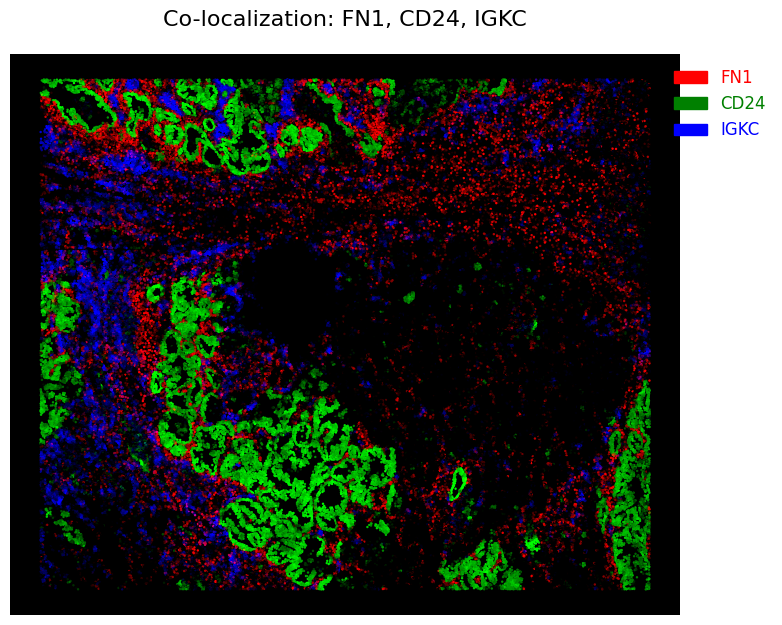

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale
import matplotlib.patches as mpatches
import scipy.sparse as sp

genes_to_plot = ['FN1', 'CD24', 'IGKC'] 
exp_data = adata[:, genes_to_plot].layers['rec']
if sp.issparse(exp_data):
    exp_data = exp_data.toarray()

rgb_colors = np.zeros((adata.shape[0], 3))

for i in range(3):
    clipped_data = np.clip(exp_data[:, i], a_min=None, a_max=np.percentile(exp_data[:, i], 99.5))
    rgb_colors[:, i] = minmax_scale(clipped_data)

coords = adata.obsm['spatial']
x = coords[:, 0]
y = coords[:, 1]
plt.rcParams['figure.figsize'] = (8, 6.5) 
fig, ax = plt.subplots()
ax.set_facecolor('black') 
scatter = ax.scatter(x, y, c=rgb_colors, s=3, edgecolors='none')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
    
red_patch = mpatches.Patch(color='red', label=genes_to_plot[0])
green_patch = mpatches.Patch(color='green', label=genes_to_plot[1])
blue_patch = mpatches.Patch(color='blue', label=genes_to_plot[2])

plt.legend(handles=[red_patch, green_patch, blue_patch], 
           loc='upper right', bbox_to_anchor=(1.15, 1), 
           fontsize=12, frameon=False, labelcolor='linecolor')

plt.title(f'Co-localization: {", ".join(genes_to_plot)}', fontsize=16, pad=20)
plt.tight_layout()
# plt.savefig('RGB_Colocalization.pdf', dpi=300, bbox_inches='tight')
plt.show()